In [12]:
import numpy as np
#from scipy.integrate import odeint
from scipy.integrate import solve_ivp as sl
import matplotlib.pyplot as plt
%matplotlib widget


#CASO DE N ROBOTS EN UN ESPACIO n-DIMENSIONAL

#todos los agentes siguen las mismas ecuaciones de trayectoria

#Definimos en una función las ecuaciones de la trayectoria 
np.random.seed(123)

def fun(w):
    f1 = 15*np.sin(2*w)
    f2 = 30*np.sin(w)*(np.sqrt(0.5*(1-0.5*(np.sin(w))**2)))
    f3 = 3+5*np.cos(2*w)
    #f1 = 10*np.sin(w)+20*np.sin(2*w)
    #f2 = 10*np.cos(w)-20*np.cos(2*w)
    #f3 = -40*np.sin(3*w)
    #f1 = (20 + 15*np.cos(2*w))*np.cos(w)
    #f2 = (20 + 15*np.cos(2*w))*np.sin(w)
    #f3 = 15 * np.sin(2*w)
    return np.array([f1, f2, f3])

#funciones phi
def phi(vec_pos):
    f = fun(vec_pos[-1])
    return vec_pos[:-1] - f

# calculamos la derivada de las ecuaciones de la trayectoria
def d_fun(w):
    #derivada central
    h = 1e-8 #paso
    df = (fun(w+h)-fun(w-h))/(2*h)
    return df

#matriz lapaciana de un grafo (los agentes están comunicados con los vecinos adyacentes)
def grafo_L(N):
    #N: nº de agentes 
    L = np.zeros([N,N])  
    
    # Llenar la diagonal con 2 
    np.fill_diagonal(L, 2)
    
    # Llenar las diagonales justo arriba y abajo de la diagonal principal con -1
    np.fill_diagonal(L[:, 1:], -1)
    np.fill_diagonal(L[1:, :], -1)
    
    # Llenar las esquinas con -1
    L[0, -1] = -1
    L[-1, 0] = -1
    
    return L

def vector_field(t,xi,k,n,N,ww,kc,L):
    #xi: posiciones de todos los agentes (vector columna con las 4 coordenadas )
    #t: tiempo
    #k: ganancias positivas
    #n: dimensiones 
    #N: nº de agentes 
    #L: matriz laplaciana de un grafo

    lista = np.arange(0,(n+1)*N+1,(n+1))
    k = k*N

    PHI = np.zeros(n*N) #lista vacía de funciones surface
    df = np.zeros(n*N)  #lista vacía de las derivadas 
    w = np.zeros(N)     #lista vacía para las coordenadas virtuales

    j = 0 
    for i in lista[:-1]: 
        x = xi[i:i+(n+1)]               #coordenada inicial + virtual de cada agente
        PHI[i-j:(i-j)+n] = phi(x)       #función surface 
        df[i-j:(i-j)+n] = d_fun(x[-1])  #derivada 
        w[j] = x[-1]                    #coordenadas virtuales 
        j += 1

    xi_eta = (-1)**n*df-k*PHI

    #sumatorio
    l = k*PHI*df
    # Convertir la matriz l en una matriz de n filas
    matriz_l = l.reshape((N, -1))
    #sumar a los largo del eje de las filas 
    suma = np.sum(matriz_l, axis=1)

    #función de coordinación 
    c = -L@np.transpose(w-ww)
    
    xi4 = (-1)**n+suma+kc*c

    #path-following guiding vector field 
    xi_eta = np.concatenate((xi_eta.reshape((N,n)),np.array([xi4]).T),axis=1)
    xi_eta = xi_eta.reshape((N*(n+1),-1)).T

    #print(PHI)

    return xi_eta[0]

#------------------------------------------------------------------------

#Parámetro de simulación 
n = 3           #dimensiones del espacio
N = 10           #nº de agentes 
ki =[1,1,2] #ganancias 

#coordenadas iniciales de los robots 
#pos = np.random.rand(N, n)*100 #filas: dimensiones
                           #columnas: nº de robots
pos = np.random.randint(-50, 51, size=(N, n))


#añadimos a la matriz de posiciones la coordenada virtual w 
w = np.ones((N,1)) #ejemplo: todos valen 1 

#concatenamos las dos matrices a lo largo de las filas 
Xi = np.concatenate((pos, w), axis=1)
Xi = Xi.reshape((N*(n+1),-1)).T #apilamos en un vector

#matriz lapaciana de un grafo 
L = grafo_L(N)

#parámetros para la componente de coordinación 
T = 2*np.pi #periodo 
Delta = T/N
kc = 300

ww = np.zeros(N)
for i in range(N):
    ww[i] = i*Delta

#resolvemos las ecuación diferencial 
#sol = odeint(vector_field,Xi[0],t,args=(ki,n,N,ww,kc,L))
sol = sl(vector_field, (0,10),Xi[0],method='LSODA',args=(ki,n,N,ww,kc,L),max_step=0.2) 

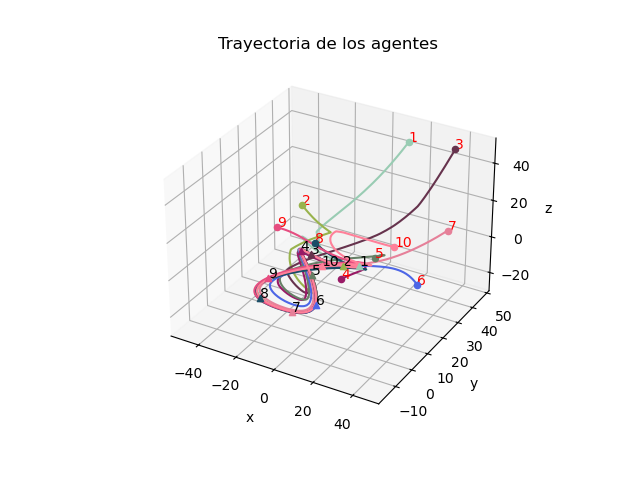

In [13]:
#representación gráfica 


fig = plt.figure()
ax = fig.add_subplot(projection='3d')

lista = np.arange(0,(n+1)*N+1,(n+1))

count = 1 

for i in lista[:-1]: 
    r = np.round(np.random.rand(),1)
    g = np.round(np.random.rand(),1)
    b = np.round(np.random.rand(),1)
    ax.plot(sol.y[i,:], sol.y[i+1,:], sol.y[i+2,:], color = [r,g,b])
    ax.scatter(sol.y[i,0],sol.y[i+1,0], sol.y[i+2,0], marker='o',color = [r,g,b])
    ax.text(sol.y[i,0],sol.y[i+1,0], sol.y[i+2,0], str(count),color ='red')
    ax.scatter(sol.y[i,-1],sol.y[i+1,-1],sol.y[i+2,-1], marker='^',color = [r,g,b])
    ax.text(sol.y[i,-1],sol.y[i+1,-1],sol.y[i+2,-1],str(count))
    count = count + 1


ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Trayectoria de los agentes')
plt.show()

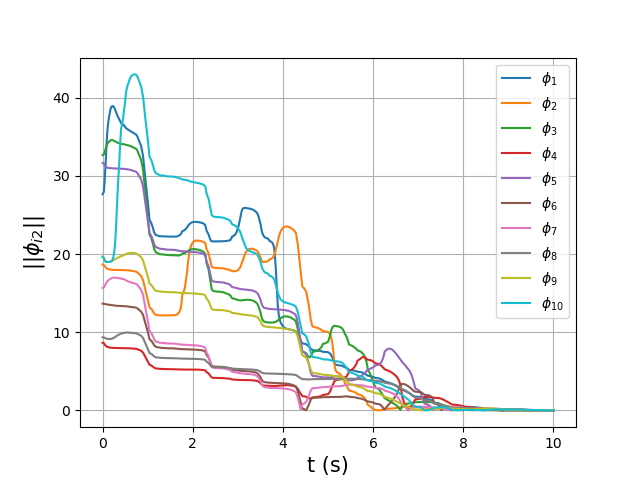

In [3]:

PHI1 = sol.y[1,:]-(30*np.sin(sol.y[3,:])*(np.sqrt(0.5*(1-0.5*(np.sin(sol.y[3,:]))**2))))
PHI2 = sol.y[5,:]-(30*np.sin(sol.y[7,:])*(np.sqrt(0.5*(1-0.5*(np.sin(sol.y[7,:]))**2))))
PHI3 = sol.y[9,:]-(30*np.sin(sol.y[11,:])*(np.sqrt(0.5*(1-0.5*(np.sin(sol.y[11,:]))**2))))
PHI4 = sol.y[13,:]-(30*np.sin(sol.y[15,:])*(np.sqrt(0.5*(1-0.5*(np.sin(sol.y[15,:]))**2))))
PHI5 = sol.y[17,:]-(30*np.sin(sol.y[19,:])*(np.sqrt(0.5*(1-0.5*(np.sin(sol.y[19,:]))**2))))
PHI6 = sol.y[21,:]-(30*np.sin(sol.y[23,:])*(np.sqrt(0.5*(1-0.5*(np.sin(sol.y[23,:]))**2))))
PHI7 = sol.y[25,:]-(30*np.sin(sol.y[27,:])*(np.sqrt(0.5*(1-0.5*(np.sin(sol.y[27,:]))**2))))
PHI8 = sol.y[29,:]-(30*np.sin(sol.y[31,:])*(np.sqrt(0.5*(1-0.5*(np.sin(sol.y[31,:]))**2))))
PHI9 = sol.y[33,:]-(30*np.sin(sol.y[35,:])*(np.sqrt(0.5*(1-0.5*(np.sin(sol.y[35,:]))**2))))
PHI10 = sol.y[37,:]-(30*np.sin(sol.y[39,:])*(np.sqrt(0.5*(1-0.5*(np.sin(sol.y[39,:]))**2))))

tt = np.linspace(0,10,np.size(PHI1))

plt.figure()
plt.grid()
plt.plot(tt,np.sqrt(PHI1**2),label=r'$\phi_{1}$')
plt.plot(tt,np.sqrt(PHI2**2),label=r'$\phi_{2}$')
plt.plot(tt,np.sqrt(PHI3**2),label=r'$\phi_{3}$')
plt.plot(tt,np.sqrt(PHI4**2),label=r'$\phi_{4}$')
plt.plot(tt,np.sqrt(PHI5**2),label=r'$\phi_{5}$')
plt.plot(tt,np.sqrt(PHI6**2),label=r'$\phi_{6}$')
plt.plot(tt,np.sqrt(PHI7**2),label=r'$\phi_{7}$')
plt.plot(tt,np.sqrt(PHI8**2),label=r'$\phi_{8}$')
plt.plot(tt,np.sqrt(PHI9**2),label=r'$\phi_{9}$')
plt.plot(tt,np.sqrt(PHI10**2),label=r'$\phi_{10}$')


plt.ylabel(r'$||\phi_{i2}$||',fontsize = 15)
plt.xlabel('t (s)',fontsize = 15)
plt.legend()
plt.show()



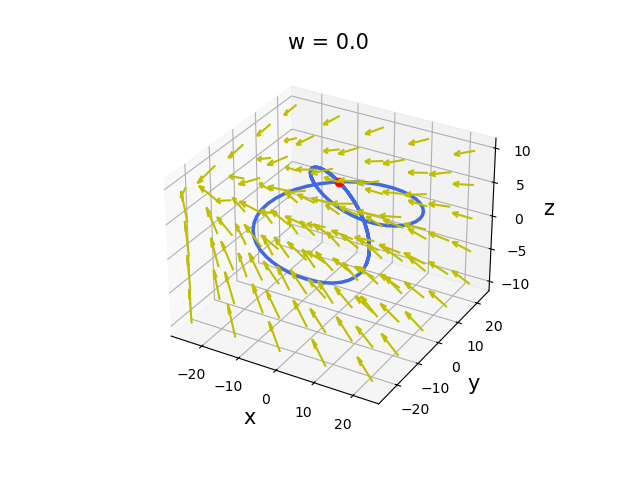

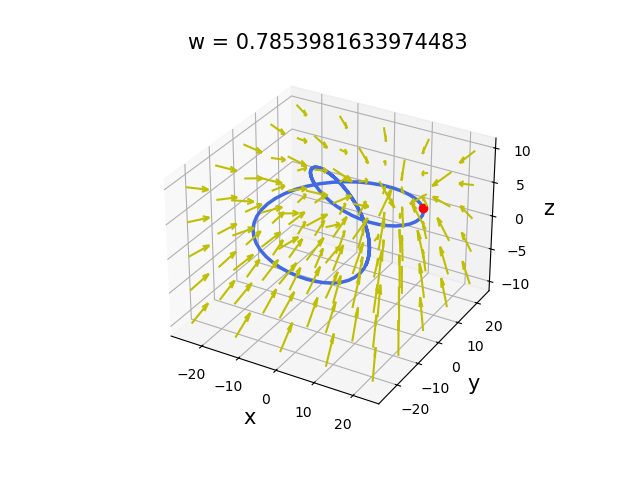

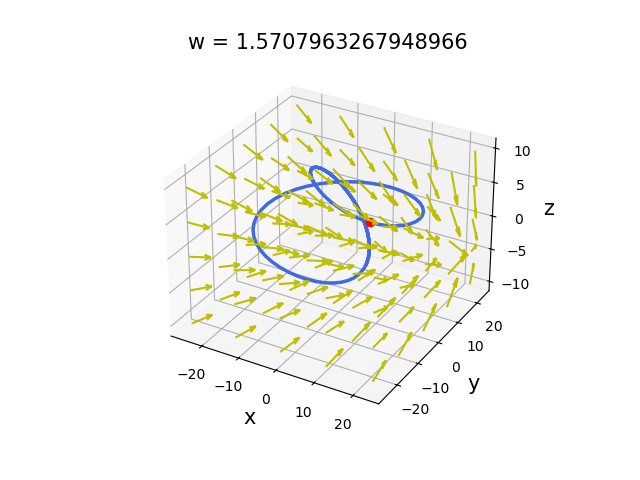

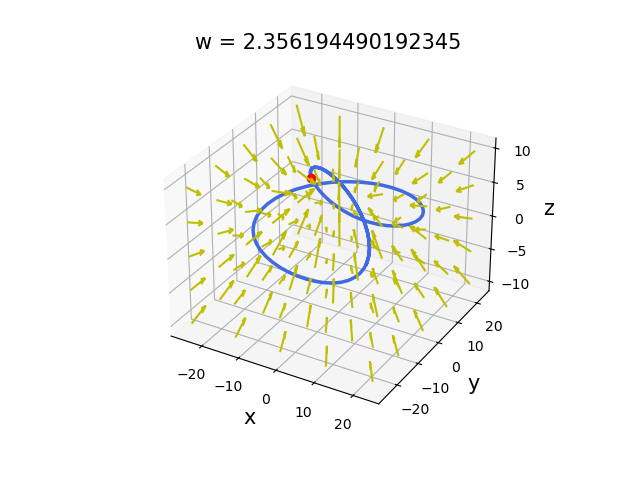

In [4]:
import numpy as np
import matplotlib.pyplot as plt 
def phi1(x,w):
    f1 = x - 15*np.sin(2*w)
    return f1
def phi2(y,w):
    f2 = y - 30*np.sin(w)*np.sqrt(0.5*(1-0.5*np.sin(w)**2))
    return f2
def phi3(z,w): 
    f3 = z - (3+5*np.cos(2*w))
    return f3 

def dphi1(w): 
    f1 = -30*np.cos(2*w)
    return f1
def dphi2(w): 
    f2 = -(15*np.cos(w)*np.sqrt(np.cos(w)**2+1))
    return f2
def dphi3(w): 
    f3 = 10 * np.sin(2*w) 
    return f3


puntos = np.arange(-25,26,12)

valores = np.linspace(-4,4,100)

[xm,ym,zm] = np.meshgrid(puntos,puntos,np.arange(-10,11,5))
K1 = 1
K2 = 1
K3 = 2

for w in np.arange(0,np.pi,np.pi/4):
    vx = phi1(xm,w)
    vy = phi2(ym,w)
    vz = phi3(zm,w)
    dx = dphi1(w)
    dy = dphi2(w)
    dz = dphi3(w)

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    #nuestra curva 
    ax.plot(15*np.sin(2*valores),30*np.sin(valores)*np.sqrt(0.5*(1-0.5*np.sin(valores)**2)),3+5*np.cos(2*valores),color="royalblue",linewidth = 2.5,zorder = 2)
    ax.scatter(15*np.sin(2*w),30*np.sin(w)*np.sqrt(0.5*(1-0.5*np.sin(w)**2)),3+5*np.cos(2*w),color = "red",linewidth = 2.5, zorder = 3)
    #campo vectorial - gradiente 
    ax.quiver(xm,ym,zm,(-K1*vx+dx),(-K2*vy+dy),(-K3*vz+dz) ,color = "y", length=5, normalize=True,zorder = 1)
    ax.set_title('w = '+str(w),  fontsize = 15)
    ax.set_xlabel("x", fontsize = 15)
    ax.set_ylabel("y", fontsize = 15)
    ax.set_zlabel("z", fontsize = 15)

Text(0.5, 0, '$w$')

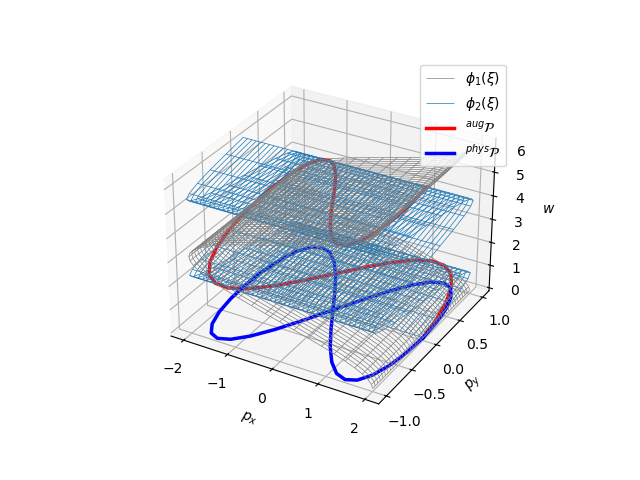

In [5]:
#import Bezier as Bz
import numpy as np
import math
import matplotlib.pyplot as pl
%matplotlib widget

#creamos unos puntos de control de la curva de bezier

w = np.arange(0,2*np.pi+np.pi/20,np.pi/20)
cx = 2*np.cos(w)
cy = np.sin(2*w)

x = np.linspace(cx.min(),cx.max(),len(cx))
y = np.linspace(cy.min(),cy.max(),len(cy))


xm,Tm = np.meshgrid(x,w)
xm,lmx = np.meshgrid(x,cx)
ym,lmy = np.meshgrid(y,cy)

ax = pl.figure().add_subplot(projection='3d')
ax.plot_wireframe(lmx,ym,Tm,linewidth=0.5,color='gray',label=r'$\phi_1(\xi)$')
ax.plot_wireframe(xm,lmy,Tm,linewidth=0.5,label=r'$\phi_2(\xi)$')
pl.plot(cx,cy,w,'r',linewidth=2.5,label=r'$^{aug}\mathcal{P}$')
pl.plot(cx,cy,np.zeros(w.shape),'b',linewidth=2.5,label=r'$^{phys}\mathcal{P}$')
ax.legend()
ax.set_xlabel(r'$p_x$')
ax.set_ylabel(r'$p_y$')
ax.set_zlabel(r'$w$')

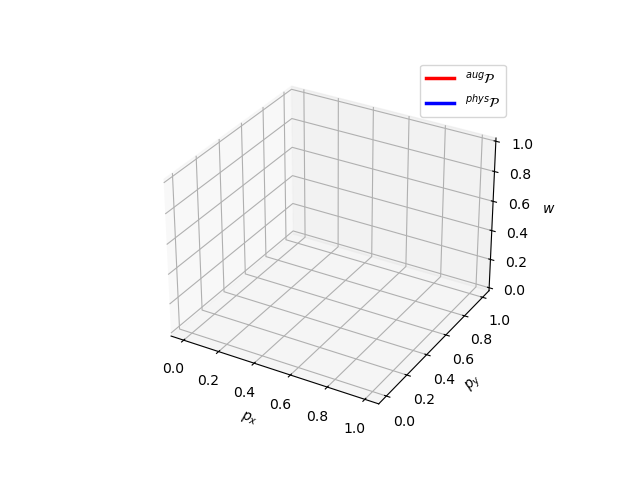

In [6]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
%matplotlib widget

# Crear puntos de control para la curva de Bézier
w = np.arange(0, 2 * np.pi + np.pi / 20, np.pi / 20)
cx = 2 * np.cos(w)
cy = np.sin(2 * w)

# Generar arrays espaciados linealmente
x = np.linspace(cx.min(), cx.max(), len(cx))
y = np.linspace(cy.min(), cy.max(), len(cy))

# Crear la figura y el eje 3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Inicializar los gráficos de la malla y las curvas
wire1 = None
wire2 = None
curve_aug, = ax.plot([], [], [], 'r', linewidth=2.5)
curve_phys, = ax.plot([], [], [], 'b', linewidth=2.5)

# Establecer etiquetas y leyenda
ax.set_xlabel(r'$p_x$')
ax.set_ylabel(r'$p_y$')
ax.set_zlabel(r'$w$')
ax.legend([curve_aug, curve_phys], [r'$^{aug}\mathcal{P}$', r'$^{phys}\mathcal{P}$'])

# Función de actualización para la animación
def update(frame):
    ax.clear()
    
    # Limitar el valor de frame
    max_frame = len(w)
    current_frame = frame % max_frame

    # Calcular el valor de w actual hasta el frame actual
    current_w = w[:current_frame]
    
    # Recalcular cx y cy con el w actual
    cx = 2 * np.cos(current_w)
    cy = np.sin(2 * current_w)
    
    # Generar mallas
    x = np.linspace(cx.min(), cx.max(), len(cx))
    y = np.linspace(cy.min(), cy.max(), len(cy))
    xm, Tm = np.meshgrid(x, current_w)
    xm, lmx = np.meshgrid(x, cx)
    ym, lmy = np.meshgrid(y, cy)
    
    # Dibujar las mallas y las curvas
    wire1 = ax.plot_wireframe(lmx, ym, Tm, linewidth=0.5, color='gray')
    wire2 = ax.plot_wireframe(xm, lmy, Tm, linewidth=0.5)
    curve_aug = ax.plot(cx, cy, current_w, 'r', linewidth=2.5)
    curve_phys = ax.plot(cx, cy, np.zeros(current_w.shape), 'b', linewidth=2.5)
    
    # Establecer límites, etiquetas y leyenda
    ax.set_xlim([-2, 2])
    ax.set_ylim([-2, 2])
    ax.set_zlim([0, 2 * np.pi])
    ax.set_xlabel(r'$p_x$')
    ax.set_ylabel(r'$p_y$')
    ax.set_zlabel(r'$w$')
    ax.legend([wire1, wire2, curve_aug[0], curve_phys[0]], [r'$\phi_1(\xi)$', r'$\phi_2(\xi)$', r'$^{aug}\mathcal{P}$', r'$^{phys}\mathcal{P}$'])
    
    return wire1, wire2, curve_aug, curve_phys

# Crear la animación
ani = FuncAnimation(fig, update, frames=np.arange(0, len(w)), interval=100)

plt.show()
